In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.7 s (started: 2026-07-02 22:12:48 +02:00)


In [2]:
scarf.fetch_dataset("tenx_5K_pbmc_rnaseq", save_path="scarf_datasets")

time: 27.4 s (started: 2026-07-02 22:12:50 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5")

time: 13.7 ms (started: 2026-07-02 22:13:17 +02:00)


In [4]:
reader.nCells, reader.nFeatures

(5025, 33538)

time: 2.16 ms (started: 2026-07-02 22:13:17 +02:00)


In [5]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

time: 29.9 s (started: 2026-07-02 22:13:17 +02:00)


In [6]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr", nthreads=4, min_features_per_cell=10
)

Minimum cell count (502) is lower than size factor multiplier (1000)



time: 5.7 s (started: 2026-07-02 22:13:46 +02:00)


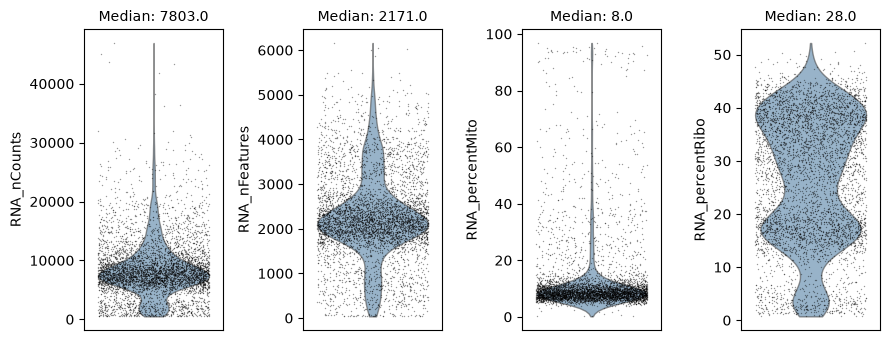

time: 1.46 s (started: 2026-07-02 22:13:52 +02:00)


In [7]:
ds.plot_cells_dists()

In [8]:
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
)

597 cells flagged for filtering out using attribute RNA_nCounts



461 cells flagged for filtering out using attribute RNA_nFeatures



612 cells flagged for filtering out using attribute RNA_percentMito



time: 79.7 ms (started: 2026-07-02 22:13:53 +02:00)


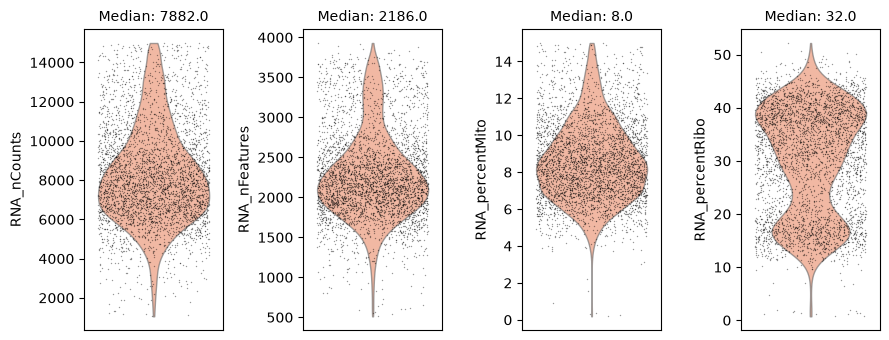

time: 1.04 s (started: 2026-07-02 22:13:53 +02:00)


In [9]:
ds.plot_cells_dists(cell_key="I", color="coral")

In [10]:
ds.cells.head()

,I,ids,names,RNA_percentRibo,RNA_percentMito,RNA_nFeatures,RNA_nCounts
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,16.783630,10.844353,3503.0,13537.0
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,20.034733,5.975687,3381.0,12668.0
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,2.494802,53.430353,346.0,962.0
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,28.783690,10.919143,1799.0,5788.0
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,35.750038,7.955407,2887.0,13186.0


time: 100 ms (started: 2026-07-02 22:13:54 +02:00)


In [11]:
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_nCounts'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 62.1 ms (started: 2026-07-02 22:13:55 +02:00)


In [12]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,5025
1,False,ENSG00000237613,FAM138A,0,5025
2,False,ENSG00000186092,OR4F5,0,5025
3,True,ENSG00000238009,AL627309.1,49,4976
4,False,ENSG00000239945,AL627309.3,3,5022


time: 68.2 ms (started: 2026-07-02 22:13:55 +02:00)


In [13]:
ds.RNA.sf

1000

time: 2.6 ms (started: 2026-07-02 22:13:55 +02:00)


Calculating summary statistics



(RNA) Computing feature stats: reading block 1/1 (rss 695 MiB)



(RNA) feature stats block 1/1: read 3.6s (r2) compute 0.5s rss 910 MiB



Calculating HVGs



498 genes marked as HVGs



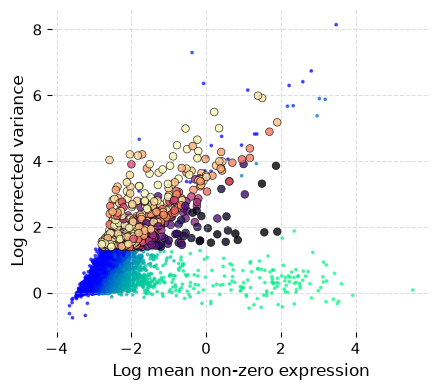

time: 6.23 s (started: 2026-07-02 22:13:55 +02:00)


In [14]:
ds.mark_hvgs(min_cells=20, top_n=500, min_mean=-3, max_mean=2, max_var=6)

In [15]:
ds.RNA.feats.head()

,I,ids,names,nCells,I__hvgs,dropOuts,stats_I_avg,stats_I_normed_n,stats_I_normed_tot,stats_I_sigmas,stats_I_nz_mean,stats_I_c_var__200__0.1
0,False,ENSG00000243485,MIR1302-2HG,0,False,5025,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,0,False,5025,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,0,False,5025,NaN,NaN,NaN,NaN,NaN,NaN
3,True,ENSG00000238009,AL627309.1,49,False,4976,0.001166,33.0,4.593283,0.000196,0.13919,1.5279
4,False,ENSG00000239945,AL627309.3,3,False,5022,NaN,NaN,NaN,NaN,NaN,NaN


time: 231 ms (started: 2026-07-02 22:14:00 +02:00)


In [16]:
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 1.2s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.92%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 15.3s (7/7 steps, 15.2s in logged steps)



time: 15.3 s (started: 2026-07-02 22:14:01 +02:00)


In [17]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

Training UMAP:   0%|                                                                                          …

time: 3.83 s (started: 2026-07-02 22:14:16 +02:00)


In [18]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label="dUMAP",
)

Training UMAP:   0%|                                                                                          …

time: 6.44 s (started: 2026-07-02 22:14:20 +02:00)


In [19]:
ds.cells.head()

,I,ids,names,RNA_percentRibo,RNA_nFeatures,RNA_percentMito,RNA_nCounts,RNA_UMAP2,RNA_UMAP1,RNA_dUMAP2,RNA_dUMAP1
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,16.783630,3503.0,10.844353,13537.0,33.366943,7.076422,31.242025,9.882455
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,20.034733,3381.0,5.975687,12668.0,33.032013,-10.396790,32.689110,-5.664997
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,2.494802,346.0,53.430353,962.0,NaN,NaN,NaN,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,28.783690,1799.0,10.919143,5788.0,13.617079,2.892304,15.158580,-4.490314
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,35.750038,2887.0,7.955407,13186.0,-8.018553,-13.576760,-6.926192,-13.716696


time: 149 ms (started: 2026-07-02 22:14:26 +02:00)


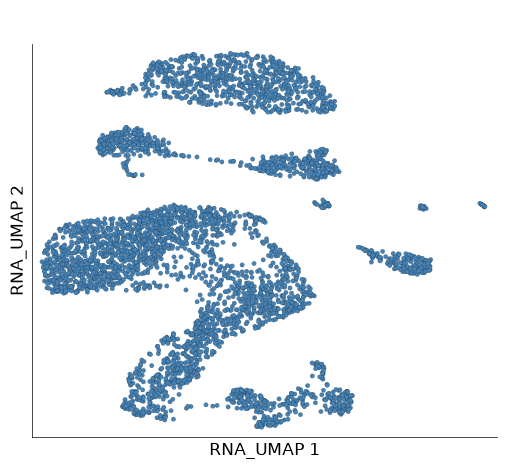

time: 137 ms (started: 2026-07-02 22:14:26 +02:00)


In [20]:
ds.plot_layout(layout_key="RNA_UMAP")

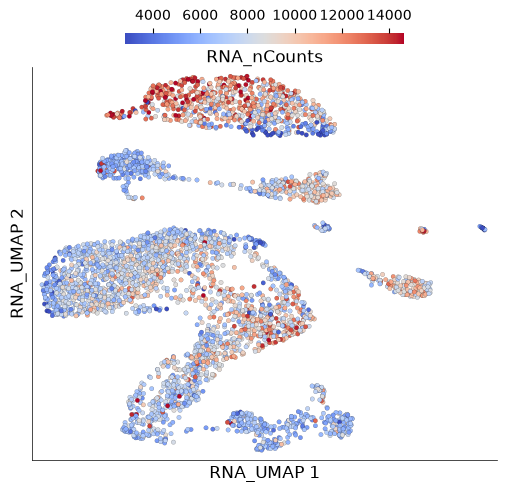

time: 283 ms (started: 2026-07-02 22:14:26 +02:00)


In [21]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_nCounts", cmap="coolwarm")

In [22]:
ds.run_tsne(alpha=10, box_h=1, early_iter=250, max_iter=500, parallel=True)

parallel=True is not supported by the sgtsnepi Python backend; running single-threaded



Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


...

Iteration 450: error is 2.98559 (50 iterations in 0.108782 seconds)


Iteration 499: error is 2.98427 (50 iterations in 0.10384 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.169025 sec [112.668%] |  Repulsive forces: -0.019005 sec [-12.6683%]


time: 995 ms (started: 2026-07-02 22:14:27 +02:00)


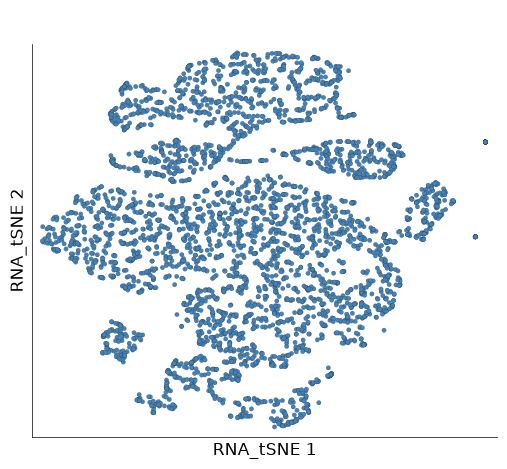

time: 198 ms (started: 2026-07-02 22:14:27 +02:00)


In [23]:
# Here we run plot_layout under exception catching because if you are not on Linux then the `run_tsne` would have failed.
try:
    ds.plot_layout(layout_key="RNA_tSNE")
except KeyError:
    print("'RNA_tSNE1' not found in MetaData")

In [24]:
# We start with Leiden clustering
ds.run_leiden_clustering(resolution=0.5)

time: 634 ms (started: 2026-07-02 22:14:27 +02:00)


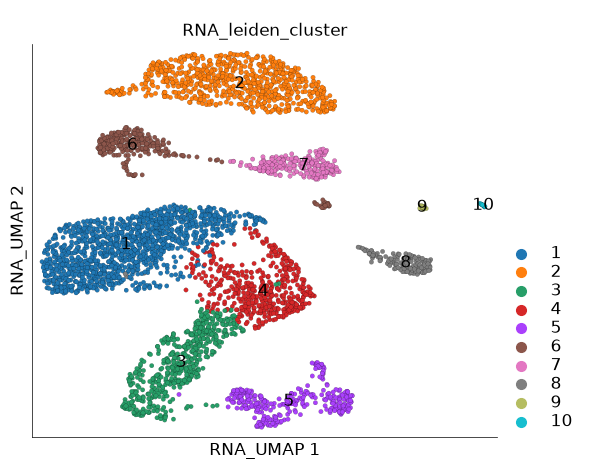

time: 323 ms (started: 2026-07-02 22:14:28 +02:00)


In [25]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_leiden_cluster")

In [26]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_tSNE1,RNA_percentRibo,RNA_tSNE2,RNA_nCounts,RNA_UMAP2,RNA_leiden_cluster,RNA_nFeatures,RNA_UMAP1,RNA_dUMAP1,RNA_dUMAP2
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,-8.643679,16.783630,19.427191,13537.0,33.366943,2,3503.0,7.076422,9.882455,31.242025
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,8.908376,20.034733,24.343671,12668.0,33.032013,2,3381.0,-10.396790,-5.664997,32.689110
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,NaN,2.494802,NaN,962.0,NaN,-1,346.0,NaN,NaN,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,7.907527,28.783690,13.020633,5788.0,13.617079,7,1799.0,2.892304,-4.490314,15.158580
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,-14.856273,35.750038,6.401667,13186.0,-8.018553,1,2887.0,-13.576760,-13.716696,-6.926192


time: 164 ms (started: 2026-07-02 22:14:28 +02:00)


In [27]:
leiden_clusters = ds.cells.to_pandas_dataframe(columns=["RNA_leiden_cluster"], key="I")
leiden_clusters.head()

,RNA_leiden_cluster
0,2
1,2
3,7
4,1
6,5


time: 40.1 ms (started: 2026-07-02 22:14:28 +02:00)


In [28]:
ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])

/tmp/ipykernel_4219/1807300542.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])


time: 312 ms (started: 2026-07-02 22:14:29 +02:00)


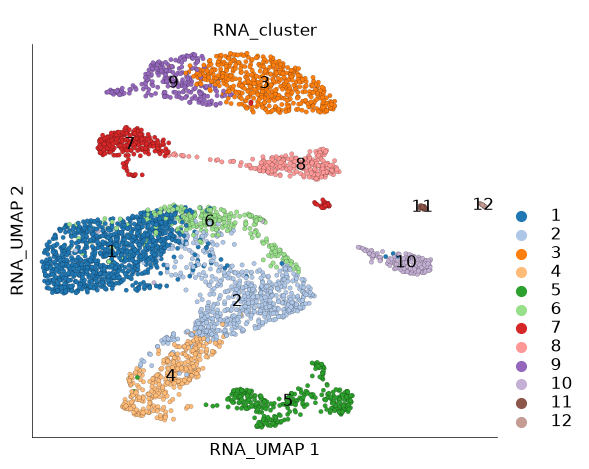

time: 269 ms (started: 2026-07-02 22:14:29 +02:00)


In [29]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_cluster")

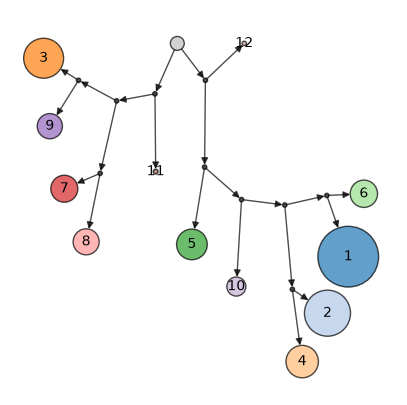

time: 292 ms (started: 2026-07-02 22:14:29 +02:00)


In [30]:
ds.plot_cluster_tree(cluster_key="RNA_cluster", width=1)

In [31]:
ds.run_marker_search(group_key="RNA_cluster", gene_batch_size=100)

Running marker search for RNA/I__RNA_cluster (feat_key=I, batch_size=100)



Marker search (fast): 14283 features, 12 groups, 143 batches of 100



(RNA) Finding markers: 14283 features in 143 batches (width 100)



Finding markers: reading block 1/143 (rss 884 MiB)



(RNA) Finding markers batch 1/143: cols=100 read 0.5s (r2) stats 0.0s rss 906 MiB



...

(RNA) Finding markers batch 142/143: cols=100 read 0.6s (ram) stats 0.0s rss 938 MiB



Finding markers: reading block 143/143 (rss 938 MiB)



(RNA) Finding markers batch 143/143: cols=83 read 0.8s (ram) stats 0.0s rss 938 MiB



Saved marker results to RNA/markers/I__RNA_cluster in 0.4s (12 clusters, layout=compact_v2)



time: 2min 5s (started: 2026-07-02 22:14:29 +02:00)


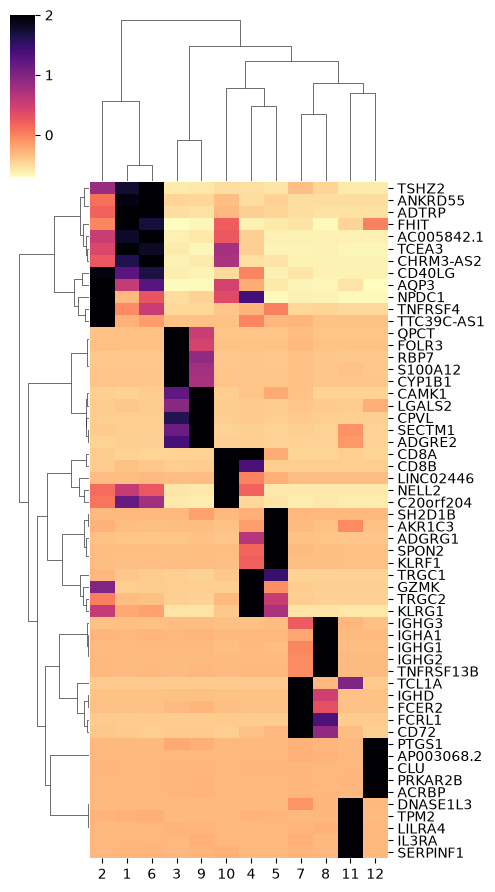

time: 1.82 s (started: 2026-07-02 22:16:33 +02:00)


In [32]:
ds.plot_marker_heatmap(group_key="RNA_cluster", topn=5, figsize=(5, 9))

In [33]:
df = ds.get_markers(
    group_key="RNA_cluster", group_id="1", min_score=-1, min_frac_exp=-1
)
df

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
0,1,ADTRP,0.39357,0.04230,0.00660,0.23891,0.04172,6.40627,7.916987e-79
1,1,FHIT,0.34500,0.14826,0.02411,0.61895,0.14213,6.14990,2.099062e-211
2,1,TSHZ2,0.33229,0.06775,0.01768,0.32157,0.07598,3.83252,4.108312e-83
3,1,TCEA3,0.32824,0.03142,0.00677,0.21169,0.04851,4.64027,1.191801e-55
4,1,ANKRD55,0.32088,0.02067,0.00345,0.13810,0.02544,5.98548,1.976907e-42
...,...,...,...,...,...,...,...,...,...
14278,1,LYN,0.00118,0.00220,0.11326,0.01815,0.39722,0.01944,1.425056e-110
14279,1,ZEB2,0.00113,0.00255,0.19569,0.01915,0.49050,0.01304,2.901976e-149
14280,1,MARCH1,0.00098,0.00070,0.09711,0.00605,0.34600,0.00716,8.621413e-97
14281,1,MEF2C,0.00091,0.00065,0.09722,0.00504,0.32972,0.00667,2.741006e-91


time: 97.8 ms (started: 2026-07-02 22:16:35 +02:00)


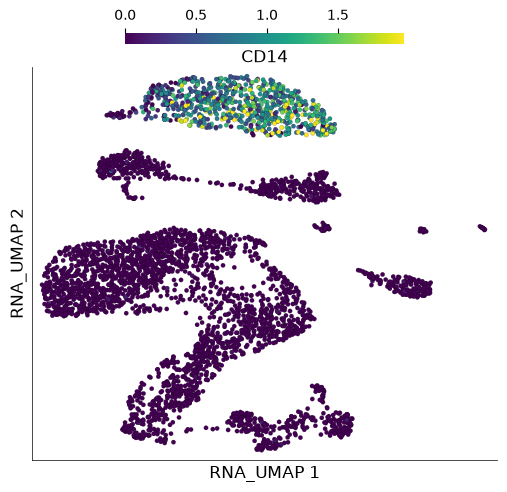

time: 1.03 s (started: 2026-07-02 22:16:35 +02:00)


In [34]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="CD14")